In [4]:
import pandas as pd
from faker import Faker

In [5]:
# 1. Initialize Faker with the Indian locale so the names and numbers look realistic!
fake = Faker('en_IN')

# 2. Load your ORIGINAL raw gym dataset
df = pd.read_csv('../data/gym_churn_us.csv') 

In [6]:
# 3. Quick Check for Missing Values
# Even though the screenshot looks clean, we always double-check.
print("--- Missing Values Check ---")
print(df.isnull().sum())

--- Missing Values Check ---
gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64


In [7]:
# 4. Final Look
print(f"\nDataset ready! Shape: {df.shape[0]} rows and {df.shape[1]} columns")
display(df.head())


Dataset ready! Shape: 4000 rows and 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Set the visual style for the charts
sns.set_theme(style="whitegrid")

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_38836\4137832867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


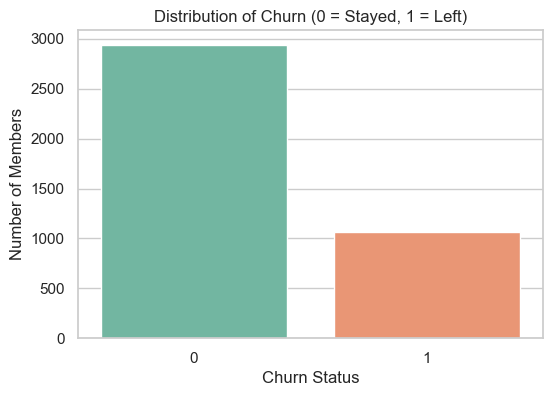

In [8]:
# 1. Check the Class Imbalance (Target Variable)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Churn (0 = Stayed, 1 = Left)')
plt.xlabel('Churn Status')
plt.ylabel('Number of Members')
plt.show()

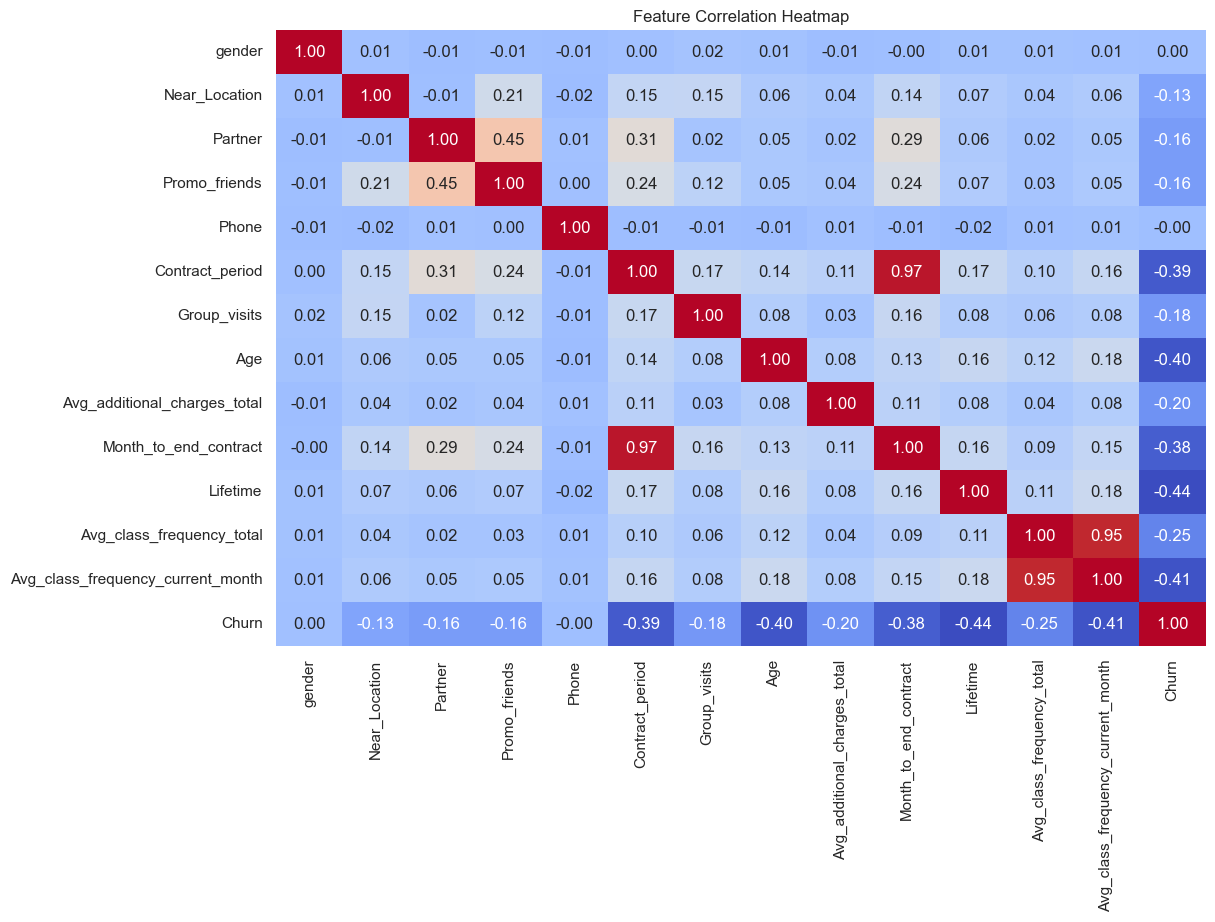

In [9]:
# 2. Correlation Heatmap (The "Cheat Sheet")
# This shows exactly which features are mathematically linked to churn
plt.figure(figsize=(12, 8))
# Compute the correlation matrix
corr_matrix = df.corr()
# Plot it using a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=False)
plt.title('Feature Correlation Heatmap')
plt.show()

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_38836\2116653421.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Contract_period', y='Churn', palette='viridis', errorbar=None)


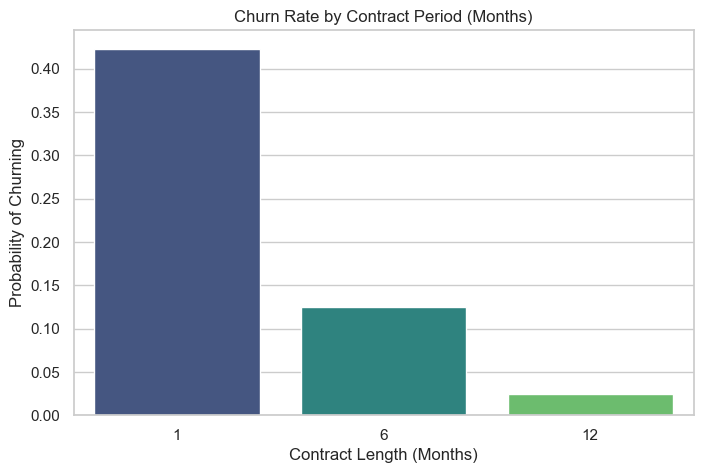

In [10]:
# 3. Business Insight: Contract Period vs. Churn
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Contract_period', y='Churn', palette='viridis', errorbar=None)
plt.title('Churn Rate by Contract Period (Months)')
plt.xlabel('Contract Length (Months)')
plt.ylabel('Probability of Churning')
plt.show()

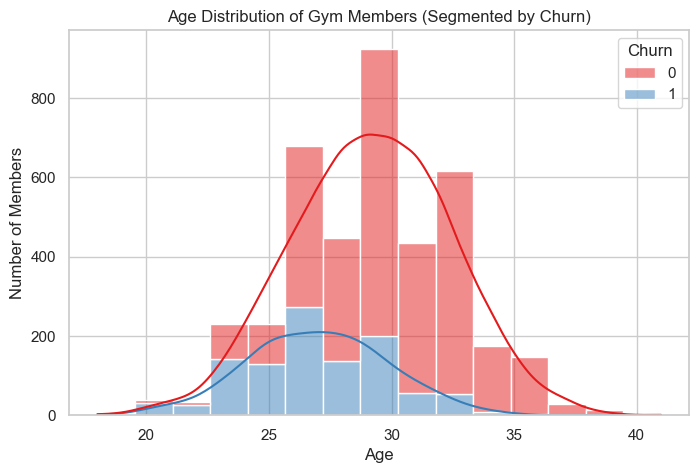

In [10]:
# 4. Demographic Insight: Age vs. Churn
# Are older or younger members more likely to quit?
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Churn', multiple='stack', bins=15, palette='Set1', kde=True)
plt.title('Age Distribution of Gym Members (Segmented by Churn)')
plt.xlabel('Age')
plt.ylabel('Number of Members')
plt.show()

In [17]:
# 1. Group the data by Age
# 'count' gives us the total people of that age.
# 'sum' gives us exactly how many of them quit (since Churn is 1 or 0).
age_stats = df.groupby('Age')['Churn'].agg(['count', 'sum']).reset_index()

# 2. Rename the columns so they look professional
age_stats.columns = ['Age', 'Total_Members', 'Total_Churned']

# 3. Calculate the actual Churn Percentage for each age group
age_stats['Churn_Rate_%'] = (age_stats['Total_Churned'] / age_stats['Total_Members']) * 100

# 4. Sort the table to show the ages with the HIGHEST number of quitters at the very top
age_stats = age_stats.sort_values(by='Total_Churned', ascending=False)

# 5. Print the top 10 highest-churning ages
print("--- EXACT CHURN COUNTS BY AGE ---")
print(age_stats.head(10).to_string(index=False))

--- EXACT CHURN COUNTS BY AGE ---
 Age  Total_Members  Total_Churned  Churn_Rate_%
  27            378            139     36.772487
  28            447            136     30.425056
  26            300            133     44.333333
  25            231            130     56.277056
  29            468            119     25.427350
  24            148             87     58.783784
  30            457             81     17.724289
  23             82             56     68.292683
  31            434             56     12.903226
  32            364             36      9.890110


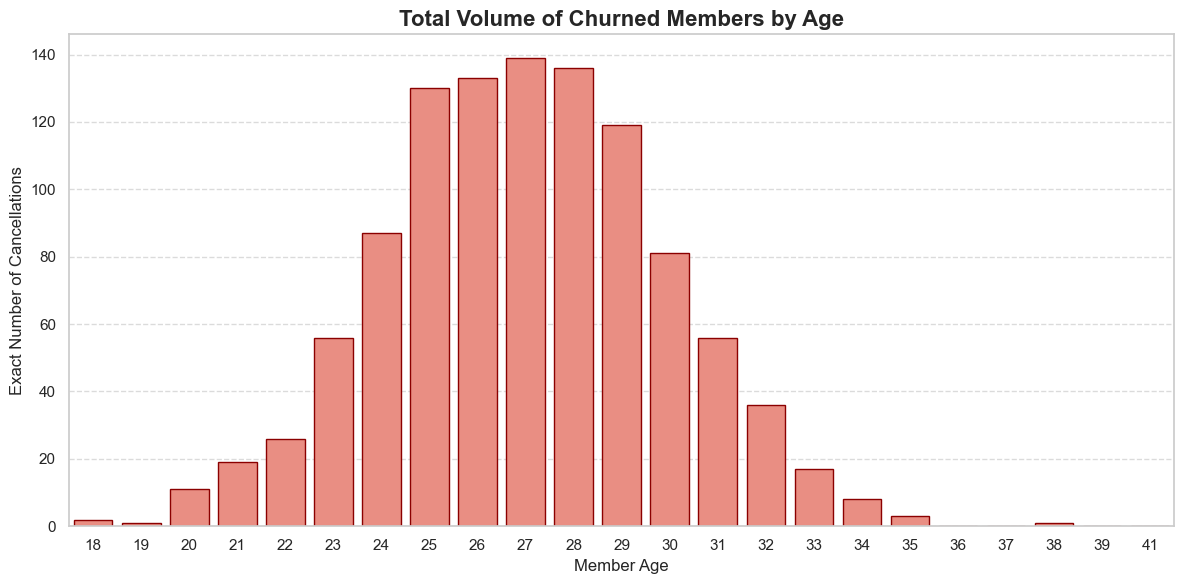

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you just ran the 'age_stats' code block above...

# 1. Sort the data by Age so the X-axis reads naturally from left to right
age_stats_sorted = age_stats.sort_values(by='Age')

# 2. Set up the canvas
plt.figure(figsize=(12, 6))

# 3. Create a Bar Plot focusing ONLY on the raw number of people who left
sns.barplot(
    data=age_stats_sorted, 
    x='Age', 
    y='Total_Churned', 
    color='salmon', 
    edgecolor='darkred'
)

# 4. Add professional labels and titles
plt.title('Total Volume of Churned Members by Age', fontsize=16, fontweight='bold')
plt.xlabel('Member Age', fontsize=12)
plt.ylabel('Exact Number of Cancellations', fontsize=12)

# 5. Add a subtle grid to make it easier to read the exact numbers
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_14984\1533834688.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='Lifetime', palette='Set3')


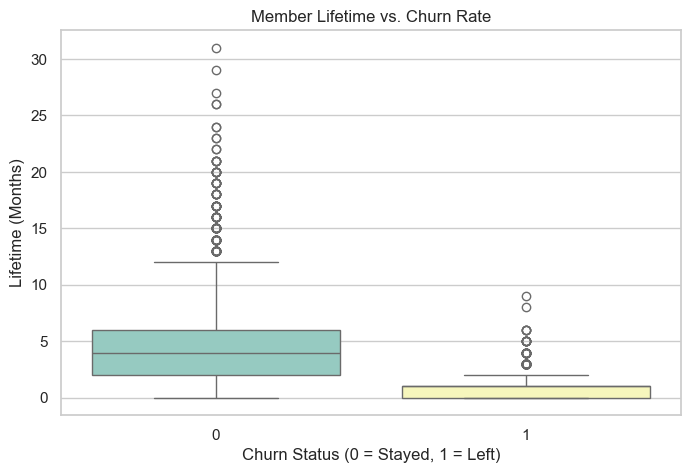

In [12]:
# 5. The Loyalty Factor: Lifetime (Months as a Member)
# Do people quit right away, or after years of loyalty?
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='Lifetime', palette='Set3')
plt.title('Member Lifetime vs. Churn Rate')
plt.xlabel('Churn Status (0 = Stayed, 1 = Left)')
plt.ylabel('Lifetime (Months)')
plt.show()

C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_14984\3334873350.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Group_visits', y='Churn', ax=axes[0], palette='pastel', errorbar=None)
C:\Users\Prathamesh\AppData\Local\Temp\ipykernel_14984\3334873350.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Promo_friends', y='Churn', ax=axes[1], palette='pastel', errorbar=None)


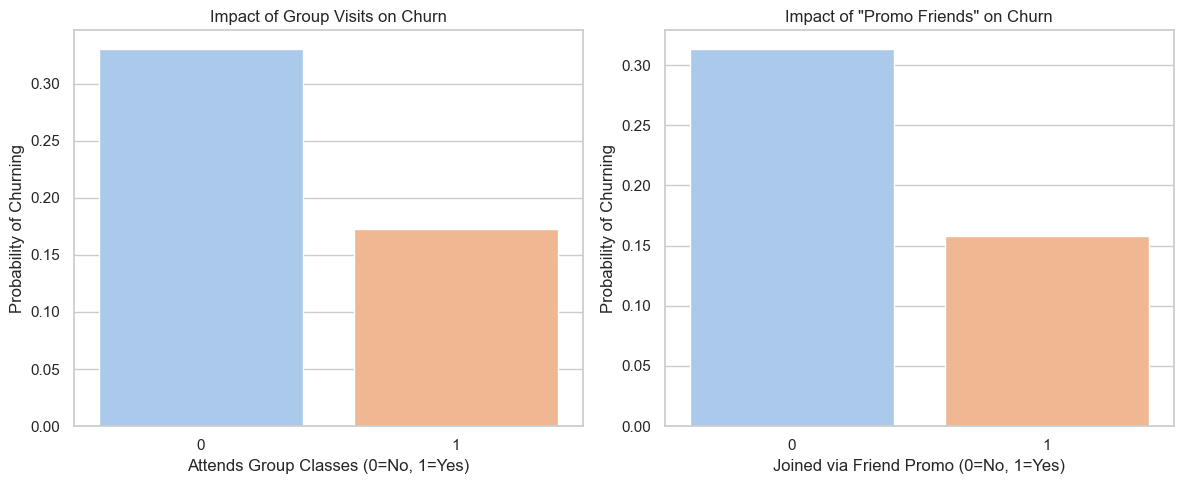

In [14]:
# 6. The Social Factor: Group Visits & Promo Friends
# Does working out with friends or in groups reduce churn?
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='Group_visits', y='Churn', ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('Impact of Group Visits on Churn')
axes[0].set_xlabel('Attends Group Classes (0=No, 1=Yes)')
axes[0].set_ylabel('Probability of Churning')

sns.barplot(data=df, x='Promo_friends', y='Churn', ax=axes[1], palette='pastel', errorbar=None)
axes[1].set_title('Impact of "Promo Friends" on Churn')
axes[1].set_xlabel('Joined via Friend Promo (0=No, 1=Yes)')
axes[1].set_ylabel('Probability of Churning')

plt.tight_layout()
plt.show()

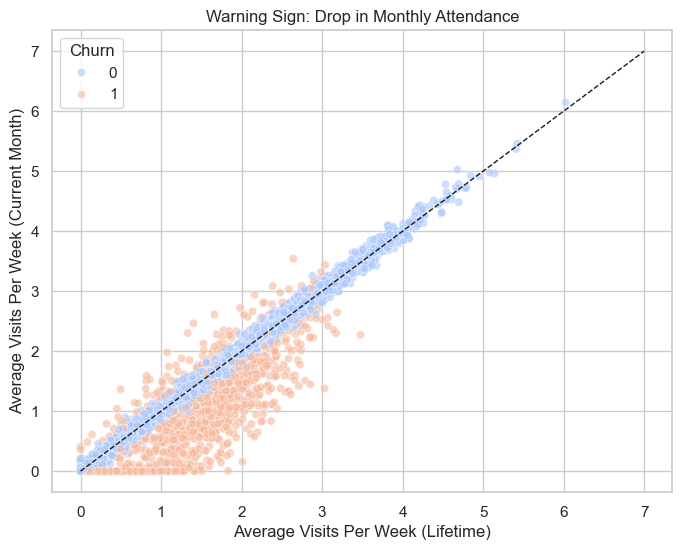

In [16]:
# 7. Behavioral Drop-off: The "Red Flag" Metric
# Comparing their historical attendance vs. this month's attendance
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Avg_class_frequency_total', 
                y='Avg_class_frequency_current_month', 
                hue='Churn', alpha=0.6, palette='coolwarm')
plt.title('Warning Sign: Drop in Monthly Attendance')
plt.xlabel('Average Visits Per Week (Lifetime)')
plt.ylabel('Average Visits Per Week (Current Month)')
# Adding a reference line where historical attendance equals current attendance
plt.plot([0, 7], [0, 7], 'k--', linewidth=1) 
plt.show()

In [2]:
print(f"Loaded {len(df)} anonymous rows. Generating identities...")

# 3. Generate the fake data
# We use a list comprehension to quickly generate a unique identity for every single row
df['Name'] = [fake.name() for _ in range(len(df))]
df['Email'] = [f"{name.lower().replace(' ', '.')}@{fake.free_email_domain()}" for name in df['Name']]
df['Phone_Number'] = [fake.phone_number() for _ in range(len(df))]

# 4. Reorder the columns so the identity is right at the front
# This makes it look like a real database
cols = ['Name', 'Phone_Number', 'Email'] + [col for col in df.columns if col not in ['Name', 'Phone_Number', 'Email']]
df = df[cols]

# 5. Let's look at the shiny new Version 2.0 dataset!
display(df.head())

Loaded 4000 anonymous rows. Generating identities...


,Name,Phone_Number,Email,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,Meghana Kapoor,2613604095,meghana.kapoor@yahoo.com,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,Ranveer Gulati,+913536032101,ranveer.gulati@gmail.com,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,Jasmit Atwal,+917702931956,jasmit.atwal@yahoo.com,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,Balveer Grover,+910855333228,balveer.grover@yahoo.com,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,Bhavna Mital,+912970962354,bhavna.mital@gmail.com,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [3]:
import numpy as np

# Apply the logic: If Phone == 1, keep the number. If Phone == 0, change it to 'No Number Provided'
df['Phone_Number'] = np.where(df['Phone'] == 1, df['Phone_Number'], 'No Number Provided')

display(df.head())

,Name,Phone_Number,Email,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,Meghana Kapoor,No Number Provided,meghana.kapoor@yahoo.com,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,Ranveer Gulati,+913536032101,ranveer.gulati@gmail.com,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,Jasmit Atwal,+917702931956,jasmit.atwal@yahoo.com,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,Balveer Grover,+910855333228,balveer.grover@yahoo.com,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,Bhavna Mital,+912970962354,bhavna.mital@gmail.com,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [4]:
# --- Feature Engineering: Version 2.0 (Corrected Column Names) ---

print("Original column count:", len(df.columns))

# 1. The Slacking Indicator (All-time average minus this month's average)
df['Attendance_Drop'] = df['Avg_class_frequency_total'] - df['Avg_class_frequency_current_month']

# 2. Contract Danger Zone (Total contract length minus months remaining)
df['Months_Served'] = df['Contract_period'] - df['Month_to_end_contract']

# 3. Age at Joining (Current age minus lifetime in years)
# We divide Lifetime by 12 to convert months to years, then round it cleanly
df['Age_at_Joining'] = round(df['Age'] - (df['Lifetime'] / 12), 1)

print("New column count:", len(df.columns))
print("\nSuccess! Here is a sneak peek at the new Brain-Boosting columns:")

# Let's display just the new columns next to the target variable (Churn) to see them
display(df[['Attendance_Drop', 'Months_Served', 'Age_at_Joining', 'Churn']].head())

Original column count: 17
New column count: 20

Success! Here is a sneak peek at the new Brain-Boosting columns:


,Attendance_Drop,Months_Served,Age_at_Joining,Churn
0,0.020398,1.0,28.8,0
1,0.012693,0.0,30.4,0
2,0.122596,0.0,27.8,0
3,-0.151582,0.0,32.8,0
4,-0.006194,0.0,25.8,0


In [5]:
# Save the upgraded Version 2.0 dataset to your hard drive
df.to_csv('../data/gym_churn_V2.csv', index=False)
print("Version 2.0 Dataset saved safely to your folder!")

Version 2.0 Dataset saved safely to your folder!


Fixing data types and generating V2 Feature Dashboard...


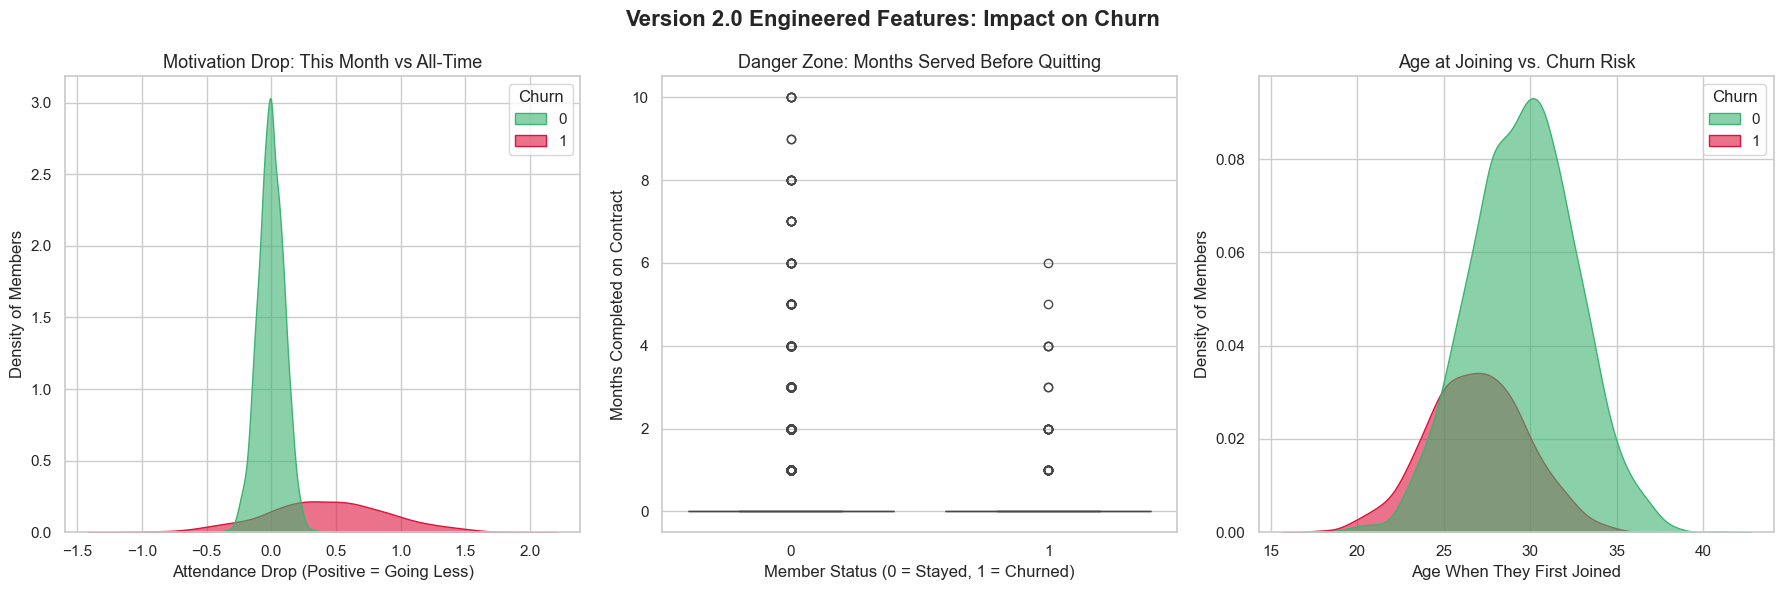

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Fixing data types and generating V2 Feature Dashboard...")

# FIX 1: Force Churn to be a math integer, not a text string!
df['Churn'] = df['Churn'].astype(int)

# Set a clean, professional visual style
sns.set_theme(style="whitegrid")

# Create a 1x3 grid for our three new features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Version 2.0 Engineered Features: Impact on Churn', fontsize=16, fontweight='bold')

# Define our consistent color palette
churn_colors = {0: 'mediumseagreen', 1: 'crimson'}

# --- Graph 1: The Slacking Indicator (Attendance_Drop) ---
sns.kdeplot(data=df, x='Attendance_Drop', hue='Churn', fill=True, 
            palette=churn_colors, ax=axes[0], alpha=0.6)
axes[0].set_title('Motivation Drop: This Month vs All-Time', fontsize=13)
axes[0].set_xlabel('Attendance Drop (Positive = Going Less)')
axes[0].set_ylabel('Density of Members')

# --- Graph 2: The Danger Zone (Months_Served) ---
# FIX 2: Added hue='Churn' and legend=False to satisfy Seaborn's new update
sns.boxplot(data=df, x='Churn', y='Months_Served', hue='Churn', legend=False,
            palette=churn_colors, ax=axes[1])
axes[1].set_title('Danger Zone: Months Served Before Quitting', fontsize=13)
axes[1].set_xlabel('Member Status (0 = Stayed, 1 = Churned)')
axes[1].set_ylabel('Months Completed on Contract')

# --- Graph 3: True Loyalty (Age_at_Joining) ---
sns.kdeplot(data=df, x='Age_at_Joining', hue='Churn', fill=True, 
            palette=churn_colors, ax=axes[2], alpha=0.6)
axes[2].set_title('Age at Joining vs. Churn Risk', fontsize=13)
axes[2].set_xlabel('Age When They First Joined')
axes[2].set_ylabel('Density of Members')

plt.tight_layout()
plt.show()

In [7]:
# --- Prepping Version 2.0 Data for Machine Learning ---

# 1. Separate the target variable (What we want to predict)
y_v2 = df['Churn']

# 2. Create the feature set (X). 
# We MUST drop the text columns (Names/Emails) and the target column (Churn)
X_v2 = df.drop(columns=['Name', 'Email', 'Phone_Number', 'Churn'])

print("Data prep complete!")
print(f"X_v2 now contains {len(X_v2.columns)} purely mathematical columns ready for the AI.")
display(X_v2.head(2))

Data prep complete!
X_v2 now contains 16 purely mathematical columns ready for the AI.


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Attendance_Drop,Months_Served,Age_at_Joining
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0.020398,1.0,28.8
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0.012693,0.0,30.4


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Prepping V2 Data for the Arena...")
# 1. Just in case, ensure X_v2 and y_v2 are perfectly clean
y_v2 = df['Churn'].astype(int)
X_v2 = df.drop(columns=['Name', 'Email', 'Phone_Number', 'Churn'], errors='ignore')

# 2. Split the V2 data (Never balance before splitting!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# 3. Scale the V2 data
scaler_v2 = StandardScaler()
X_train = scaler_v2.fit_transform(X_train_raw)
X_test = scaler_v2.transform(X_test_raw)

# 4. Define the 3 Imbalance Techniques
samplers = {
    'Random_Oversampling': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

# 5. Define the 4 Algorithms
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42), 
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 6. The V2 Engine Room Loop
results_v2 = []
print("Starting the V2 Model Showdown... Please wait while all 12 models train.\n")

for sampler_name, sampler in samplers.items():
    print(f"Applying {sampler_name}...")
    # Balance the training data
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    
    for model_name, model in models.items():
        # Train the model
        model.fit(X_resampled, y_resampled)
        
        # Make predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate scores
        results_v2.append({
            'Balancing Technique': sampler_name,
            'Algorithm': model_name,
            'Accuracy': round(accuracy_score(y_test, y_pred), 4),
            'Precision': round(precision_score(y_test, y_pred), 4),
            'Recall': round(recall_score(y_test, y_pred), 4),
            'F1-Score': round(f1_score(y_test, y_pred), 4),
            'AUC': round(roc_auc_score(y_test, y_pred_proba), 4)
        })

# 7. Create the V2 Leaderboard
leaderboard_v2 = pd.DataFrame(results_v2)

# Sort by the highest AUC
leaderboard_v2 = leaderboard_v2.sort_values(by='AUC', ascending=False).reset_index(drop=True)

print("\n--- VERSION 2.0 EXPERIMENT COMPLETE ---")
display(leaderboard_v2)

Prepping V2 Data for the Arena...
Starting the V2 Model Showdown... Please wait while all 12 models train.

Applying Random_Oversampling...


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:09:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Applying SMOTE...


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:09:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Applying ADASYN...

--- VERSION 2.0 EXPERIMENT COMPLETE ---


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:09:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Balancing Technique,Algorithm,Accuracy,Precision,Recall,F1-Score,AUC
0,Random_Oversampling,XGBoost,0.9450,0.9072,0.8713,0.8889,0.9846
1,SMOTE,XGBoost,0.9437,0.8945,0.8812,0.8878,0.9817
2,ADASYN,XGBoost,0.9387,0.8768,0.8812,0.8790,0.9806
3,Random_Oversampling,SVM,0.9337,0.8565,0.8861,0.8710,0.9774
4,SMOTE,SVM,0.9337,0.8634,0.8762,0.8698,0.9764
5,ADASYN,SVM,0.9287,0.8251,0.9109,0.8659,0.9762
6,Random_Oversampling,Random Forest,0.9437,0.9067,0.8663,0.8861,0.9761
7,ADASYN,Random Forest,0.9375,0.8725,0.8812,0.8768,0.9734
8,SMOTE,Random Forest,0.9437,0.9067,0.8663,0.8861,0.9720
9,SMOTE,Logistic Regression,0.9113,0.7937,0.8762,0.8329,0.9699


🛠️ PRE-FLIGHT CHECK: LOADING & PREPPING DATA
✅ Data successfully loaded, split, and scaled!

🚀 PHASE 1: ROS + XGBOOST EXPERIMENT

1. Applying Random Oversampling (ROS)...
   -> Original Training Rows: 3200
   -> New Training Rows:      4682
   -> DATASET INCREASED BY:   1482 synthetic rows injected!

2. Training XGBoost & Calculating Metrics...

--- ROS + XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       598
           1       0.91      0.87      0.89       202

    accuracy                           0.94       800
   macro avg       0.93      0.92      0.93       800
weighted avg       0.94      0.94      0.94       800

--- ROC AUC SCORE: 0.9846 ---

Generating 4-in-1 Dashboard...


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:10:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


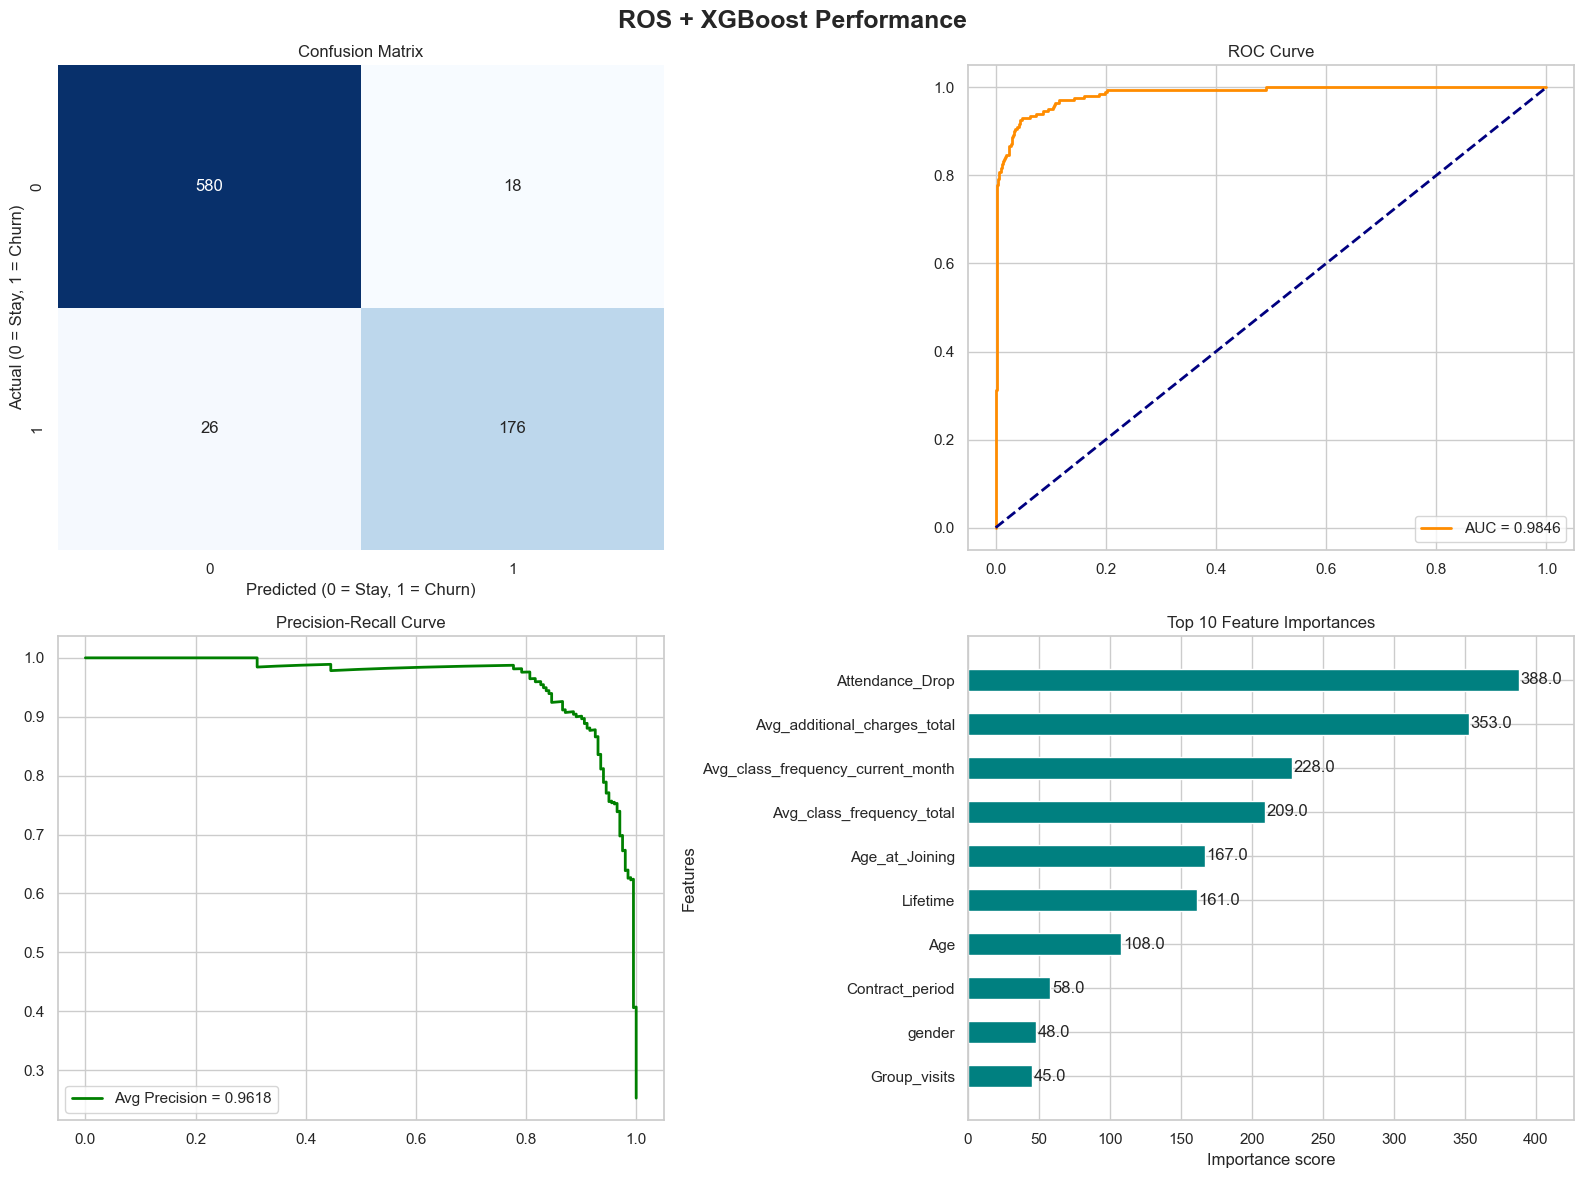


3. Implementing SHAP on ROS + XGBoost...


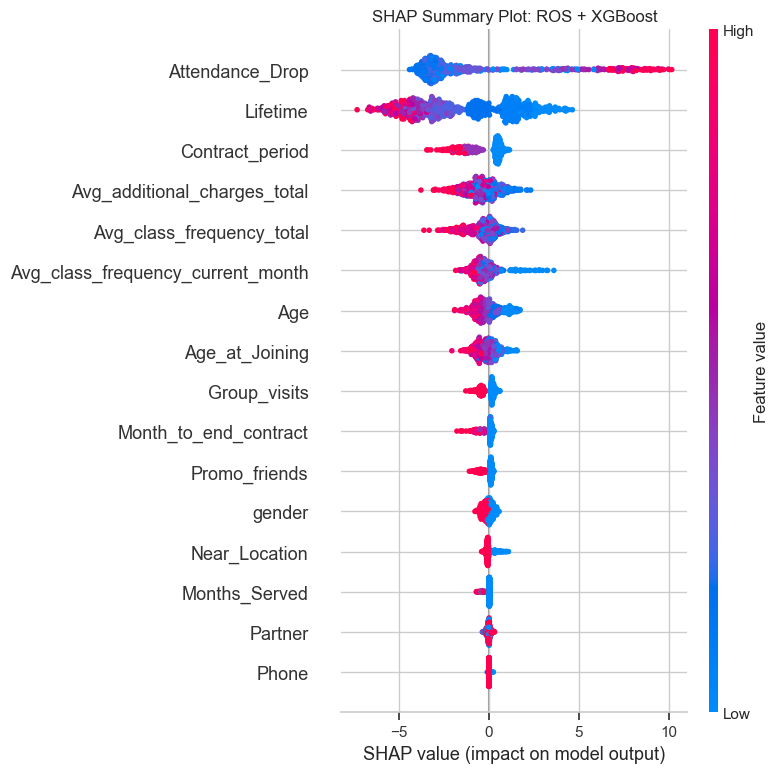


✅ Phase 1 Complete!


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

print("==================================================")
print("🛠️ PRE-FLIGHT CHECK: LOADING & PREPPING DATA")
print("==================================================")

# 1. Load the V2 dataset from your specific data folder
df = pd.read_csv('../data/gym_churn_V2.csv')

# 2. Separate target and features (ignoring text columns)
y_v2 = df['Churn']
X_v2 = df.drop(columns=['Name', 'Email', 'Phone_Number', 'Churn'], errors='ignore')

# 3. Split the data
X_train_raw, X_test_raw, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.2, random_state=42)

# 4. Scale the data
scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_raw)
X_test_scaled_v2 = scaler_v2.transform(X_test_raw)

# Extract feature names so our charts look professional
feature_names = X_v2.columns.tolist()
print("✅ Data successfully loaded, split, and scaled!")

print("\n==================================================")
print("🚀 PHASE 1: ROS + XGBOOST EXPERIMENT")
print("==================================================")

# --- STEP 1: Use ROS & Calculate Dataset Increase ---
print("\n1. Applying Random Oversampling (ROS)...")
ros = RandomOverSampler(random_state=42)
orig_size = len(y_train_v2)
X_train_ros, y_train_ros = ros.fit_resample(X_train_scaled_v2, y_train_v2)
new_size = len(y_train_ros)

print(f"   -> Original Training Rows: {orig_size}")
print(f"   -> New Training Rows:      {new_size}")
print(f"   -> DATASET INCREASED BY:   {new_size - orig_size} synthetic rows injected!")

# Convert arrays back to DataFrames to preserve column names for charts
X_train_ros_df = pd.DataFrame(X_train_ros, columns=feature_names)
X_test_scaled_df = pd.DataFrame(X_test_scaled_v2, columns=feature_names)

# --- STEP 2: Train XGBoost, Print Metrics, & Plot 4 Graphs ---
print("\n2. Training XGBoost & Calculating Metrics...")
model_ros = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_ros.fit(X_train_ros_df, y_train_ros)

y_pred_ros = model_ros.predict(X_test_scaled_df)
y_pred_proba_ros = model_ros.predict_proba(X_test_scaled_df)[:, 1]
auc_score_ros = roc_auc_score(y_test_v2, y_pred_proba_ros)

print("\n--- ROS + XGBoost Classification Report ---")
print(classification_report(y_test_v2, y_pred_ros))
print(f"--- ROC AUC SCORE: {auc_score_ros:.4f} ---\n")

print("Generating 4-in-1 Dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ROS + XGBoost Performance', fontsize=18, fontweight='bold')

# Graph A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test_v2, y_pred_ros), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# Graph B: ROC Curve
fpr, tpr, _ = roc_curve(y_test_v2, y_pred_proba_ros)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score_ros:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc="lower right")

# Graph C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_v2, y_pred_proba_ros)
ap_score = average_precision_score(y_test_v2, y_pred_proba_ros)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc="lower left")

# Graph D: Feature Importance
plot_importance(model_ros, ax=axes[1, 1], max_num_features=10, height=0.5, color='teal')
axes[1, 1].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

# --- STEP 3: Implement SHAP Explainability ---
print("\n3. Implementing SHAP on ROS + XGBoost...")
explainer_ros = shap.TreeExplainer(model_ros)
shap_values_ros = explainer_ros.shap_values(X_test_scaled_df)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: ROS + XGBoost")
shap.summary_plot(shap_values_ros, X_test_scaled_df, show=False)
plt.show()

print("\n✅ Phase 1 Complete!")

🚀 PHASE 2: SMOTE + XGBOOST EXPERIMENT

4. Applying SMOTE...
   -> Original Training Rows: 3200
   -> New Training Rows:      4682
   -> DATASET INCREASED BY:   1482 synthetic rows injected!

5. Training XGBoost & Calculating Metrics...


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- SMOTE + XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       598
           1       0.89      0.88      0.89       202

    accuracy                           0.94       800
   macro avg       0.93      0.92      0.93       800
weighted avg       0.94      0.94      0.94       800

--- ROC AUC SCORE: 0.9817 ---

Generating 4-in-1 Dashboard...


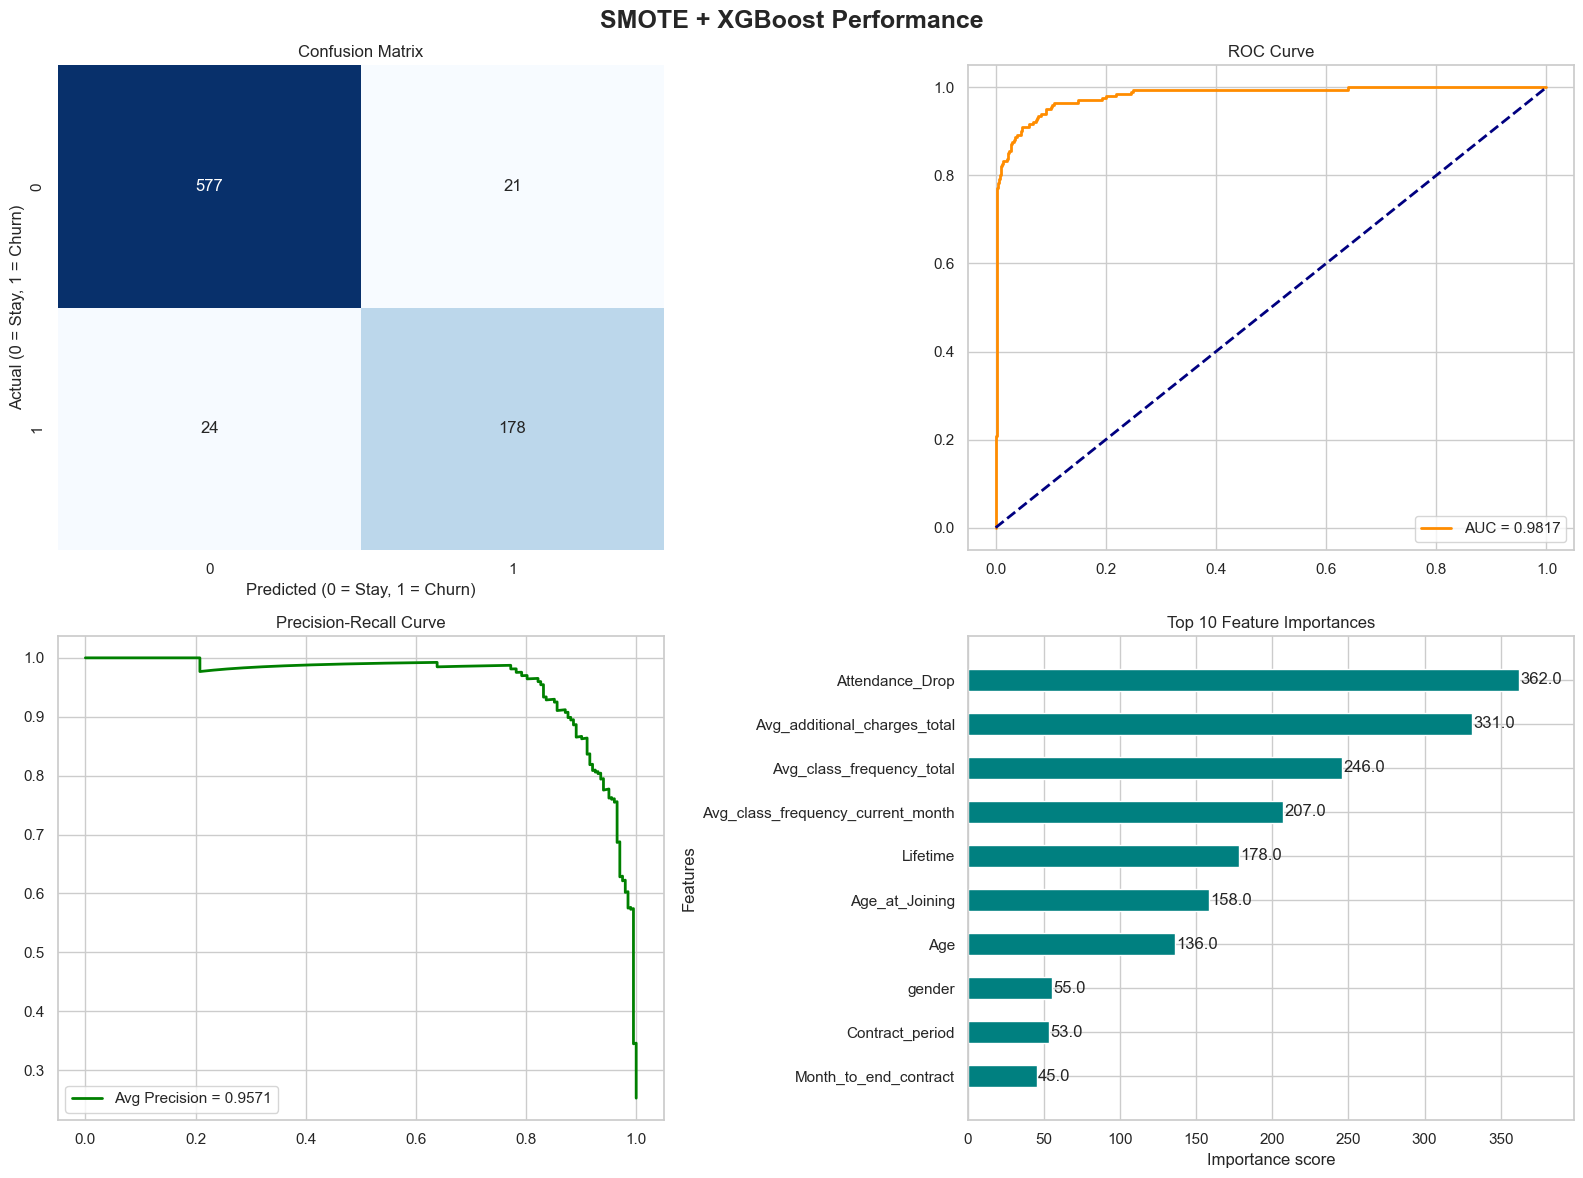


6. Implementing SHAP on SMOTE + XGBoost...


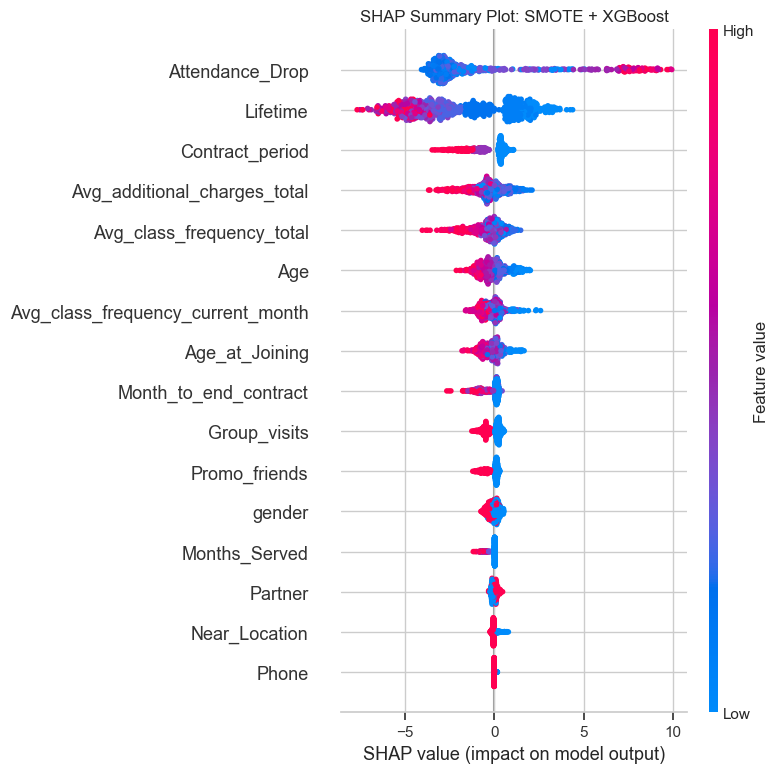


✅ Phase 2 Complete!


In [10]:
from imblearn.over_sampling import SMOTE

print("==================================================")
print("🚀 PHASE 2: SMOTE + XGBOOST EXPERIMENT")
print("==================================================")

# --- STEP 4: Use SMOTE & Calculate Dataset Increase ---
print("\n4. Applying SMOTE...")
smote = SMOTE(random_state=42)
orig_size_smote = len(y_train_v2)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled_v2, y_train_v2)
new_size_smote = len(y_train_smote)

print(f"   -> Original Training Rows: {orig_size_smote}")
print(f"   -> New Training Rows:      {new_size_smote}")
print(f"   -> DATASET INCREASED BY:   {new_size_smote - orig_size_smote} synthetic rows injected!")

# Convert arrays back to DataFrames to preserve column names for charts
X_train_smote_df = pd.DataFrame(X_train_smote, columns=feature_names)

# --- STEP 5: Train XGBoost, Print Metrics, & Plot 4 Graphs ---
print("\n5. Training XGBoost & Calculating Metrics...")
model_smote = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_smote.fit(X_train_smote_df, y_train_smote)

y_pred_smote = model_smote.predict(X_test_scaled_df)
y_pred_proba_smote = model_smote.predict_proba(X_test_scaled_df)[:, 1]
auc_score_smote = roc_auc_score(y_test_v2, y_pred_proba_smote)

print("\n--- SMOTE + XGBoost Classification Report ---")
print(classification_report(y_test_v2, y_pred_smote))
print(f"--- ROC AUC SCORE: {auc_score_smote:.4f} ---\n")

print("Generating 4-in-1 Dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SMOTE + XGBoost Performance', fontsize=18, fontweight='bold')

# Graph A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test_v2, y_pred_smote), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# Graph B: ROC Curve
fpr, tpr, _ = roc_curve(y_test_v2, y_pred_proba_smote)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score_smote:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc="lower right")

# Graph C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_v2, y_pred_proba_smote)
ap_score = average_precision_score(y_test_v2, y_pred_proba_smote)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc="lower left")

# Graph D: Feature Importance
plot_importance(model_smote, ax=axes[1, 1], max_num_features=10, height=0.5, color='teal')
axes[1, 1].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

# --- STEP 6: Implement SHAP Explainability ---
print("\n6. Implementing SHAP on SMOTE + XGBoost...")
explainer_smote = shap.TreeExplainer(model_smote)
shap_values_smote = explainer_smote.shap_values(X_test_scaled_df)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: SMOTE + XGBoost")
shap.summary_plot(shap_values_smote, X_test_scaled_df, show=False)
plt.show()

print("\n✅ Phase 2 Complete!")

🚀 PHASE 3: ADASYN + XGBOOST EXPERIMENT

7. Applying ADASYN...
   -> Original Training Rows: 3200
   -> New Training Rows:      4766
   -> DATASET INCREASED BY:   1566 synthetic rows injected!

8. Training XGBoost & Calculating Metrics...


C:\Users\Prathamesh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:15:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- ADASYN + XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       598
           1       0.88      0.88      0.88       202

    accuracy                           0.94       800
   macro avg       0.92      0.92      0.92       800
weighted avg       0.94      0.94      0.94       800

--- ROC AUC SCORE: 0.9806 ---

Generating 4-in-1 Dashboard...


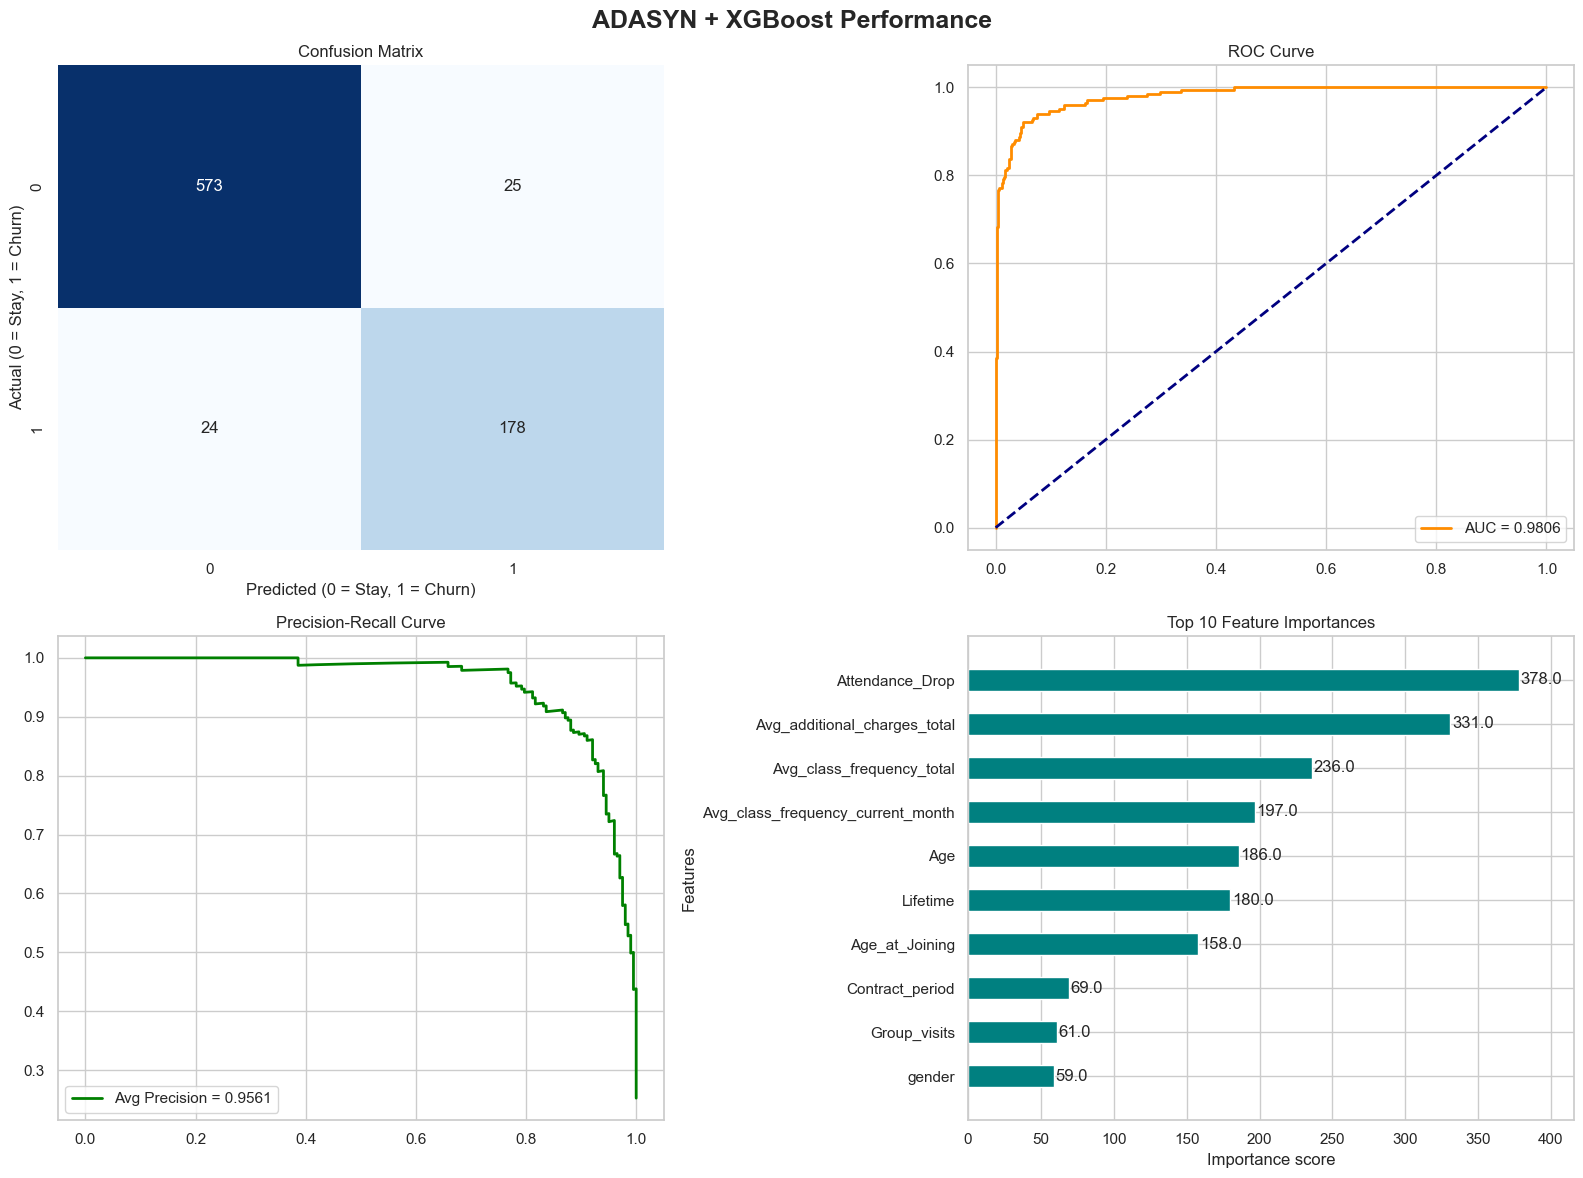


9. Implementing SHAP on ADASYN + XGBoost...


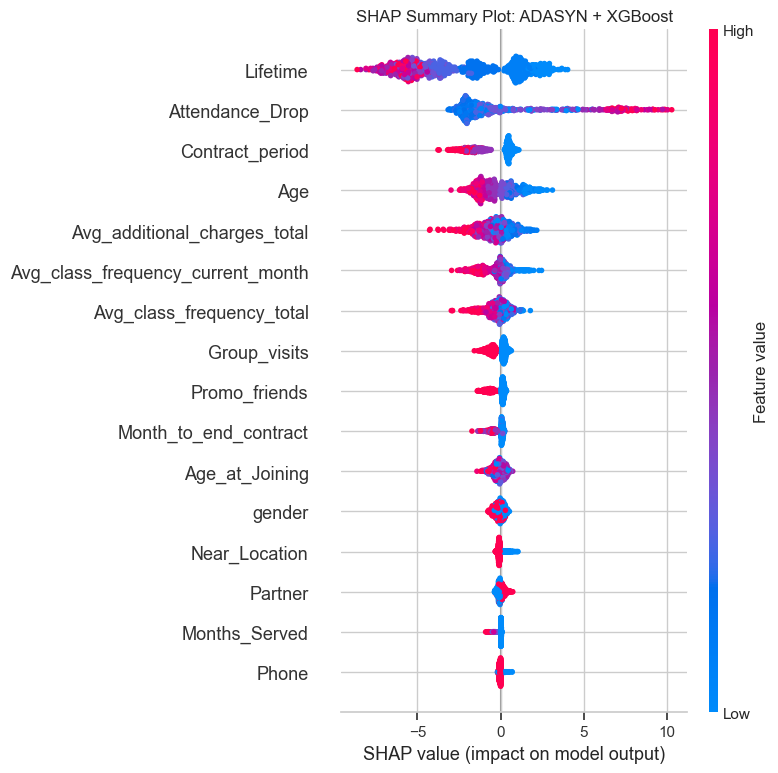


💾 STEP 10: EXPORTING ALL MODELS TO /APP FOLDER
✅ ROS Engine Saved!
✅ SMOTE Engine Saved!
✅ ADASYN Engine Saved!
✅ V2 Scaler Saved!

🎉 JUPYTER NOTEBOOK WORK IS OFFICIALLY 100% COMPLETE! 🎉


In [11]:
from imblearn.over_sampling import ADASYN
import joblib
import os

print("==================================================")
print("🚀 PHASE 3: ADASYN + XGBOOST EXPERIMENT")
print("==================================================")

# --- STEP 7: Use ADASYN & Calculate Dataset Increase ---
print("\n7. Applying ADASYN...")
adasyn = ADASYN(random_state=42)
orig_size_adasyn = len(y_train_v2)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled_v2, y_train_v2)
new_size_adasyn = len(y_train_adasyn)

print(f"   -> Original Training Rows: {orig_size_adasyn}")
print(f"   -> New Training Rows:      {new_size_adasyn}")
print(f"   -> DATASET INCREASED BY:   {new_size_adasyn - orig_size_adasyn} synthetic rows injected!")

# Convert arrays back to DataFrames to preserve column names for charts
X_train_adasyn_df = pd.DataFrame(X_train_adasyn, columns=feature_names)

# --- STEP 8: Train XGBoost, Print Metrics, & Plot 4 Graphs ---
print("\n8. Training XGBoost & Calculating Metrics...")
model_adasyn = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model_adasyn.fit(X_train_adasyn_df, y_train_adasyn)

y_pred_adasyn = model_adasyn.predict(X_test_scaled_df)
y_pred_proba_adasyn = model_adasyn.predict_proba(X_test_scaled_df)[:, 1]
auc_score_adasyn = roc_auc_score(y_test_v2, y_pred_proba_adasyn)

print("\n--- ADASYN + XGBoost Classification Report ---")
print(classification_report(y_test_v2, y_pred_adasyn))
print(f"--- ROC AUC SCORE: {auc_score_adasyn:.4f} ---\n")

print("Generating 4-in-1 Dashboard...")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ADASYN + XGBoost Performance', fontsize=18, fontweight='bold')

# Graph A: Confusion Matrix
sns.heatmap(confusion_matrix(y_test_v2, y_pred_adasyn), annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted (0 = Stay, 1 = Churn)')
axes[0, 0].set_ylabel('Actual (0 = Stay, 1 = Churn)')

# Graph B: ROC Curve
fpr, tpr, _ = roc_curve(y_test_v2, y_pred_proba_adasyn)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc_score_adasyn:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc="lower right")

# Graph C: Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_v2, y_pred_proba_adasyn)
ap_score = average_precision_score(y_test_v2, y_pred_proba_adasyn)
axes[1, 0].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {ap_score:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend(loc="lower left")

# Graph D: Feature Importance
plot_importance(model_adasyn, ax=axes[1, 1], max_num_features=10, height=0.5, color='teal')
axes[1, 1].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

# --- STEP 9: Implement SHAP Explainability ---
print("\n9. Implementing SHAP on ADASYN + XGBoost...")
explainer_adasyn = shap.TreeExplainer(model_adasyn)
shap_values_adasyn = explainer_adasyn.shap_values(X_test_scaled_df)

plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: ADASYN + XGBoost")
shap.summary_plot(shap_values_adasyn, X_test_scaled_df, show=False)
plt.show()

# --- STEP 10: Save Everything via Joblib ---
print("\n==================================================")
print("💾 STEP 10: EXPORTING ALL MODELS TO /APP FOLDER")
print("==================================================")
if not os.path.exists('../app'):
    os.makedirs('../app')

# Exporting the models we built in memory across all 3 phases
joblib.dump(model_ros, '../app/model_ros_xgb.pkl')
print("✅ ROS Engine Saved!")
joblib.dump(model_smote, '../app/model_smote_xgb.pkl')
print("✅ SMOTE Engine Saved!")
joblib.dump(model_adasyn, '../app/model_adasyn_xgb.pkl')
print("✅ ADASYN Engine Saved!")
joblib.dump(scaler_v2, '../app/gym_scaler_v2.pkl')
print("✅ V2 Scaler Saved!")

print("\n🎉 JUPYTER NOTEBOOK WORK IS OFFICIALLY 100% COMPLETE! 🎉")